**<font color=skyblue>PCA 與 SVD 在影像處理的應用（一）</font>**

- 影像圖片的壓縮概念、壓縮倍數與壓縮的品質。
- 影像圖片與檔案的儲存。

參考講義：https://ntpuccw.blog/python-in-learning/sml%e6%b7%ba%e5%ba%a6%e6%a9%9f%e5%99%a8%e5%ad%b8%e7%bf%92%ef%bc%9apca-%e3%80%81svd-%e5%8f%8a%e5%85%b6%e5%9c%a8%e5%bd%b1%e5%83%8f%e8%99%95%e7%90%86%e7%9a%84%e6%87%89%e7%94%a8/


<hr>
<font color=yellow>SVD 指令使用</font>

- numpy.linalg.svd
- sklearn.decomposition.TruncatedSVD：使用手冊 https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html
<hr>

Import necessary packages
注意：使用 <font color=yellow>pip install scikit-image</font> 安裝 skimage 套件

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimgx
from skimage import io
from numpy.linalg import svd
from sklearn.decomposition import TruncatedSVD

簡單的 SVD 實驗：Let $X$ be an $m\times n$ matrix.

$$X = U\Sigma V^T$$
$$Z_q = U_q^TX$$
$$X_q = U_q\Sigma_q V_q^T = U_qZ_q = U_qU_q^TX$$

where 
- $U$ is an $m\times m$ orthogonal matrix, $\Sigma$ is an $m\times n$ diagonal matrix with non-negative real numbers on the diagonal, and $V^T$ is an $n\times n$ orthogonal matrix.
- $U_q$, $m\times q$, is the first $q$ columns of $U$, $\Sigma_q$ is the $q\times q$ diagonal matrix with the first $q$ singular values, and $V_q^T$, $q\times n$, is the first $q$ rows of $V^T$.
- The derived matrix $Z_q$ is a $q\times n$ matrix and $X_q$ is an $m\times n$ matrix.

下列程式碼採兩個方式計算 $Z_q, X_q$：
- 使用 numpy.linalg.svd 套件進行 SVD 分解，並引用上述的公式。
- 直接採用 sklearn.decomposition.TruncatedSVD 套件取得。


In [3]:
X = np.array([[3,4,3],[1,2,3],[4,2,1]])
U, E, VT = svd(X, full_matrices = False) # full_matrices=True
# X_ = U @ np.diag(E) @ VT # 還原

q = 2 # how many components (dimensions) to keep

Zq = U[:, :q].T @ X # the transformed matrix
Xq = U[:, :q] @ U[:, :q].T @ X # projection matrix
# print Zq and Xq to decimal places for better readability
Zq = np.round(Zq, decimals=1)
Xq = np.round(Xq, decimals=1)
print("Zq by formula:\n", Zq) # the transformed matrix
print("Xq by formula:\n", Xq) # projection matrix
# --------------------------------------
#Fitting the SVD class
X = X.T # (n_features, n_samples)
Tsvd =  TruncatedSVD(n_components = q) # does not center the data
Tsvd.fit(X) # 留意 X 的维度代表的意義：(n_samples, n_features)
X_transformed = Tsvd.transform(X) # (n_samples, n_features)
# print(Tsvd.singular_values_) # the singular values
# print(Tsvd.components_) # the right singular vectors
Z_q = np.round(X_transformed.T, decimals=1) 
print("Z_q by TruncatedSVD:\n", Z_q) # the transformed matrix
Xq = (X_transformed @ Tsvd.components_).T
Xq = np.round(Xq, decimals=1)
print("X_q by TruncatedSVD:\n", Xq) # projection matrix


Zq by formula:
 [[-4.7 -4.8 -4. ]
 [ 1.9 -0.5 -1.7]]
Xq by formula:
 [[3.1 3.6 3.3]
 [0.9 2.4 2.7]
 [3.9 2.2 0.9]]
Z_q by TruncatedSVD:
 [[ 4.7  4.8  4. ]
 [ 1.9 -0.5 -1.7]]
X_q by TruncatedSVD:
 [[3.1 3.6 3.3]
 [0.9 2.4 2.7]
 [3.9 2.2 0.9]]


<hr>
<font color=yellow>Image compression</font>

- 先讀取影像檔並呈現出來
- 留意影像大小的表達：剛好相反
    - 描述一張影像的大小為：水平方向像素 x 垂直方向像素。
    - 描述一個矩陣的大小為：列數 x 行數
<hr>

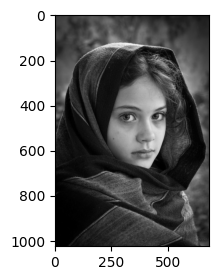

In [4]:
# imgfile = "pictures/Lenna.png" # 512x512x3
imgfile = "pictures/afghan_girl_3.jpg" # 683x1024x3
X = io.imread(imgfile, as_gray = True) # 直接讀取為灰階圖像，大小為 1024x683
# X = mpimg.imread(imgfile)
# if len(X.shape) > 2:
#     X = np.mean(X, axis=2) # convert RGB to grayscale

fig = plt.figure(figsize=(3, 3))
plt.imshow(X, cmap = 'gray')
plt.show()

<hr>
<font color=yellow>利用 Rank q approximation 的公式進行影像壓縮</font>

$$X_q = \sum_{i=1}^{q} \sigma_i \underline{u}_i \underline{v}_i^T = U_q \Sigma_q V_q^T$$

$q$ 的大小決定壓縮倍數，壓縮倍數越大，影像品質越差。

注意：
- 單張影像是一個矩陣，其行向量或列向量並無特別意義，即既非代表樣本也非特徵。
- 影像壓縮的意義在令影像檔變小，以利儲存、傳送。但壓縮檔並非影像檔，必須經過解壓縮方能恢復影像。若 $X$ 矩陣為一張影像，則 $Z_q=U_q^TX$ 為壓縮影像，$X_q=U_qZ_q$ 為解壓縮影像。即$X_q$ 亦可以表達為 $X_q=U_qU_q^TX$。
- 壓縮通常以影像品質作為代價，壓縮倍數愈高，影像品質愈差，稱為「破壞性壓縮」（lossy compression）。常用的 JPG、PNG 影像檔的壓縮方式不同，但也是破壞性壓縮。
- 壓縮倍數 = 原影像大小 / $q$($\sigma_i$ + $\underline{u}_i$ +  $\underline{v}_i$ 的長度）。
<hr>

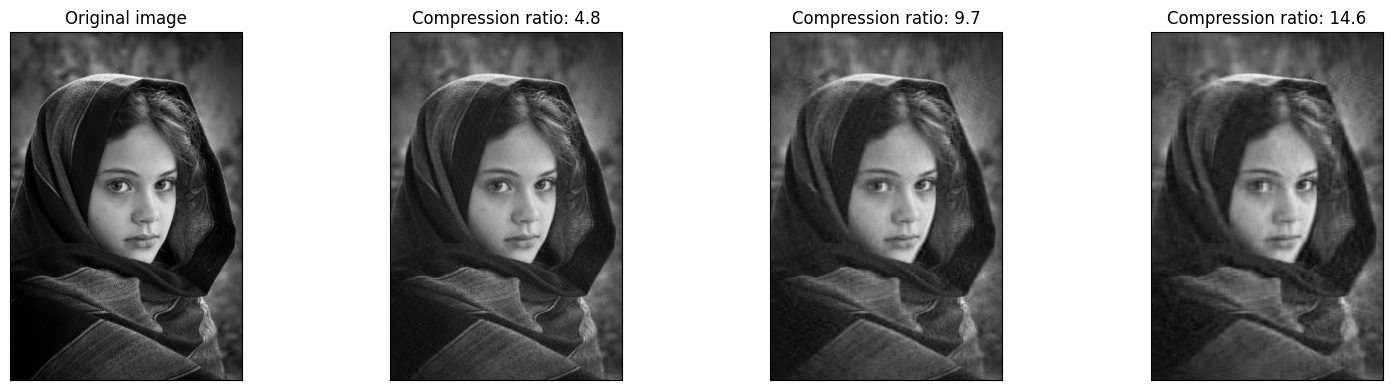

In [5]:
imgfile = "pictures/afghan_girl_3.jpg" # 683x1024x3
X = io.imread(imgfile, as_gray = True) # 1024x683

m, n = X.shape # m x n
U, E, VT = svd(X, full_matrices = False) # 只取必要的部分，留意 U 與 VT 的维度
q = (min(m, n) / np.array([1, 8, 16, 24])).astype('int') # how many components (dimensions) to keep

fig, ax = plt.subplots(1, len(q), figsize=(16, 4))
for i, r in enumerate(q):
    Xq = U[:, :r] @ np.diag(E[:r]) @ VT[:r, :] 
    ax[i].imshow(Xq, cmap = 'gray')
    ratio = m * n / (U.shape[0] + VT.shape[1] + 1) / r # compression ratio
    if ratio >= 1:
         ax[i].set_title('Compression ratio: {:.1f}'.format(ratio))
    else:
         ax[i].set_title('Original image')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.tight_layout()
plt.show()

<font color=yellow>利用 Truncated SVD 做影像壓縮</font>

壓縮倍數 = 原影像大小 /(q($Z_q$ 大小 + $V_q$ 大小 + 1))

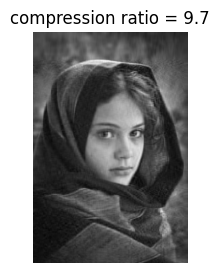

In [6]:
m, n = X.shape 
q = 42
Tsvd = TruncatedSVD(n_components = q, random_state = 0).fit(X)
Zq = Tsvd.transform(X) # 壓縮影像
Xq = Tsvd.inverse_transform(Zq) # 解壓縮影像（重建影像）
# Xq =X @ Tsvd.components_.T @ Tsvd.components_ # projection matrix
fig = plt.figure(figsize=(3, 3))
plt.imshow(Xq, cmap = 'gray')
Ratio = m * n / (Zq.shape[0] + Tsvd.components_.shape[1] + 1) / q
plt.title(f"compression ratio = {Ratio:.1f}")
plt.axis('off')
plt.show()

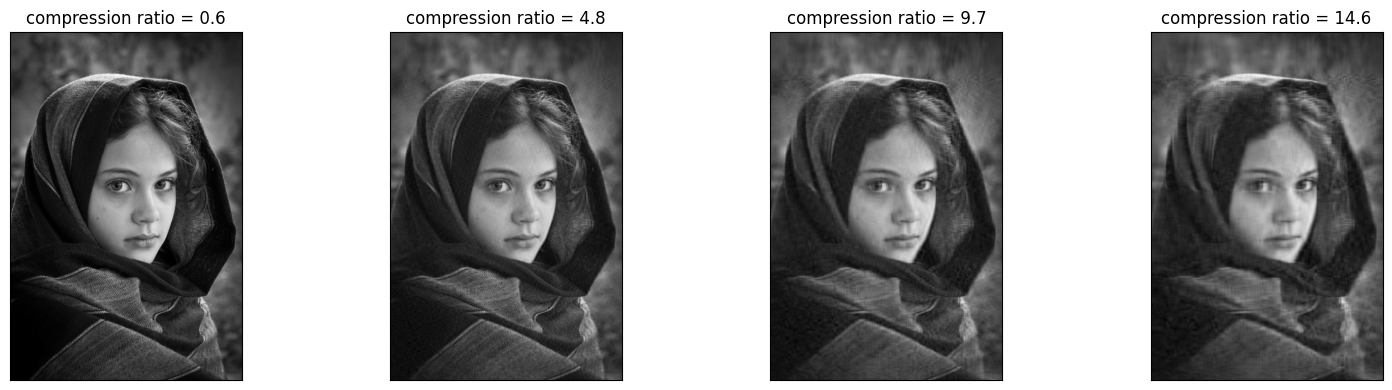

In [7]:
m, n = X.shape 
q = (min(m, n) / np.array([1, 8, 16, 24])).astype('int') # how many components (dimensions) to keep

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i, r in enumerate(q):
    Tsvd = TruncatedSVD(n_components = r, random_state = 0).fit(X)
    Xq = X @ Tsvd.components_.T @ Tsvd.components_ # projection matrix
    # Zq = Tsvd.fit_transform(X) # compress
    # Xq = Tsvd.inverse_transform(Zq) # decompress
    ax[i].imshow(Xq, cmap = 'gray')
    Ratio = m * n / (Zq.shape[0] + Tsvd.components_.shape[1] + 1) / r # compression ratio
    if r >= 1:
         ax[i].set_title(f"compression ratio = {Ratio:.1f}")
    else:
         ax[i].set_title('Original image')
    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.tight_layout()
plt.show()

<font color=yellow>將影像重組後再壓縮</font>

有時候將資料進行前處理（preprocessing）後再進行 SVD 分解，會得到更好的壓縮效果。
- 將一張影像矩陣 $X$ 從上而下，自左至右切割成一張張 $s \times s$ 的小矩陣（patch）。
- 然後將每個 patch 拉成 $1\times s^2$ 的列向量，並組合成新的矩陣 $M$。
- 對 $M$ 進行 SVD 分解，取前 $q$ 個分量，成為 $M_q$。
- 再將 $M_q$ 依原來切割的順序，重組回到原來的影像的結構，即為 $X_q$。

<font color=yellow>蒙太奇圖函數</font>

- 大批影像資料經常以矩陣方式儲存。儲存方式為將每張影像拉成向量，譬如列向量，再從上而下一張張堆疊成矩陣。
- 下列函數假設輸入矩陣 $A$ 含有 $M$ 張圖，其中每張被拉成（reshape）成 $1\times N$ 向量，因此 $A$ 的大小為 $M\times N$。
- 本函數呈現 $A$ 矩陣所含的 $M$ 張圖中的前 mn 張圖，並排列成 $m\times n$ 的大圖，稱為蒙太奇圖（Momtage figure）

In [8]:
def montage(A, m, n):
    '''
    Create a montage matrix with mn images
    Inputs:
    A: original MxN image matrix with M images (N pixels/image), M > mn
    m, n: m rows & n columns, total mn images
    Output:
    M: montage matrix containing mn images
    '''
    
    sz = np.sqrt(A.shape[1]).astype('int') # image size sz x sz
    M = np.zeros((m*sz, n*sz)) # montage image
    
    for i in range(m) :
        for j in range(n) :
            M[i*sz: (i+1)*sz, j*sz:(j+1)*sz] = \
                A[i*n+j,:].reshape(sz, sz)

    return M

1. <font color=skyblue>以 patch size=16 x 16 的切割圖為例</font>

- 譬如將矩陣 $X：1024\times 683$ 切割並重組為 $M：2732\times 256$
- 對 $M$ 進行 SVD 分解，取前 $q$ 項組合為 $M_q$。
- 再將 $M_q$ 重新排列為 $X_q$。
- 從 $M_q$ 的組合計算壓縮比，再比較 $X_q$ 的壓縮品質。

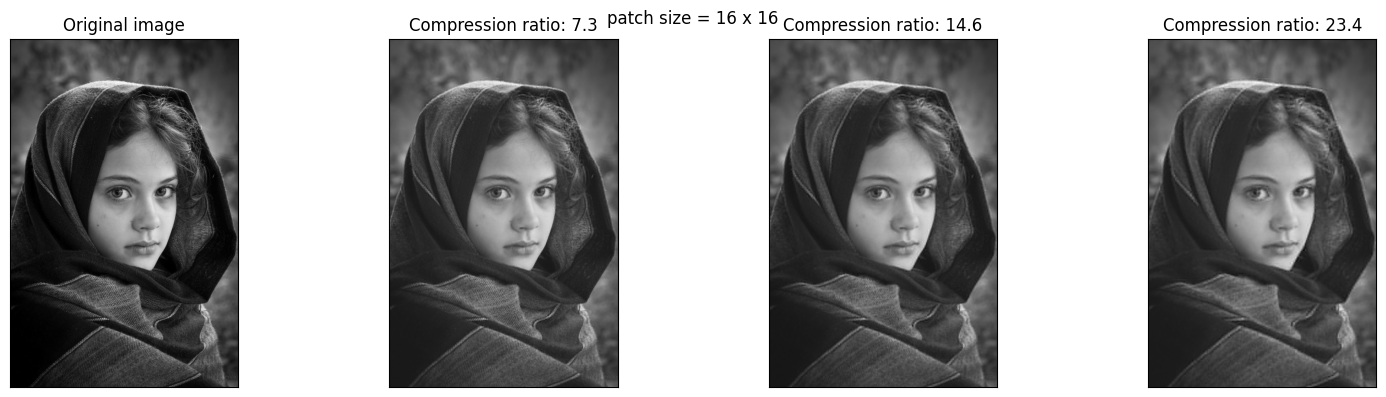

In [9]:
# -------------------------------------------------------------
imgfile = "pictures/afghan_girl_3.jpg" # 683x1024x3
X = io.imread(imgfile, as_gray = True)

# -------------------------------------------------------------
N, p = X.shape # 刻意以 N 代表樣本數， p 代表特徵數
# create a new matrix with size N_patch x p_patch
patch_sz = 16
p_patch = patch_sz ** 2 
# N_patch = int(N * p / p_patch)
N_patch = int(N / patch_sz) * int(p / patch_sz)
# Reassemble the image into a matrix M with size N_patch x p_patch, 
# where each row is a patch of the image
M = np.zeros((N_patch, p_patch)) 
for i in range(int(N/patch_sz)) :
    for j in range(int(p/patch_sz)) :
        M[i*int(p/patch_sz)+j,:] = \
        X[i*patch_sz: (i+1)*patch_sz, j*patch_sz:(j+1)*patch_sz].reshape(1,-1) 
                
# plt.imshow(M, cmap = 'gray')
U, E, VT = svd(M, full_matrices = False)
# q = np.array([256, 102, 51, 25]).astype('int')
q = (min(N_patch, p_patch) / np.array([1, 8, 16, 24])).astype('int') # how many components (dimensions) to keep

fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i, r in enumerate(q):
    Mq = U[:, :r] @ np.diag(E[:r]) @ VT[:r, :] 
    ax[i].imshow(montage(Mq, int(N/patch_sz), int(p/patch_sz)), cmap = 'gray')
    ratio = N_patch * p_patch / (U.shape[0] + VT.shape[1] + 1) / r
    if i >= 1:
        ax[i].set_title('Compression ratio: {:.1f}'.format(ratio))
    else:
        ax[i].set_title('Original image')

    ax[i].set_xticks([])
    ax[i].set_yticks([])
plt.tight_layout()
plt.suptitle("patch size = {} x {}".format(patch_sz, patch_sz))
plt.show()


<font color=yellow>探討：</font>

- 將矩陣作如此重組，有可能在相同的壓縮比下產生更好的品質嗎？（從視覺來看）
- 不同的 patch size 會有不同的壓縮品質嗎？愈大愈好？還是愈小愈好？還是不一定？
- 要回答上述問題，必須改寫程式，方便在相同的壓縮比之下，觀察不同 patch size 的壓縮品質。
- 另，如過用別張圖，是否也是如上述的結果？譬如用 Lenna.png 圖。

<hr>

2. <font color=skyblue>同上，練習使用套件 scikit-image 來切割影像 X 成 patches，方便組合成 M，再從 M 回到 X</font>

注意：這個切割方法只能保留 patch 整數倍的列與行，多餘的行列會拋棄。


Total number of patches: 2688
Size of each patch: 256


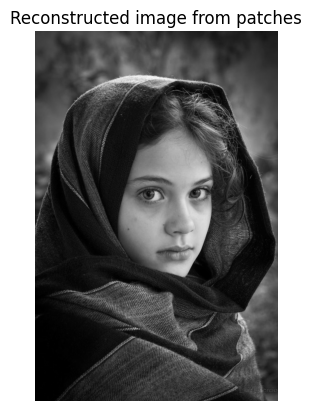

In [10]:
# use skimage.util.view_as_windows to get patches
from skimage.util import view_as_windows

imgfile = "pictures/afghan_girl_3.jpg" # 683x1024x3
# imgfile = "pictures/Lenna.png" # 512x512x3
X = io.imread(imgfile, as_gray = True)

patch_size = 16
patches = view_as_windows(X, window_shape=(patch_size, patch_size), \
                          step=patch_size)
M = patches.reshape(-1, patch_size * patch_size) # flatten the patches

print("Total number of patches:", M.shape[0])
print("Size of each patch:", M.shape[1])
# 將 M 重組回到 X 的形狀
X_reconstructed = montage(M, patches.shape[0], patches.shape[1]) # 
plt.imshow(X_reconstructed, cmap='gray')
plt.title("Reconstructed image from patches")
plt.axis('off')
plt.show()

使用套件 scikit-image.view_as_windows 進行圖像切割與重組
- 對圖像做 patches 分割
- 將 patches 組合成新矩陣 M
- 對 M 做 SVD，取前 q 項，得近似矩陣 Mq
- 將 Mq 重組回圖像結構，得到 Xq

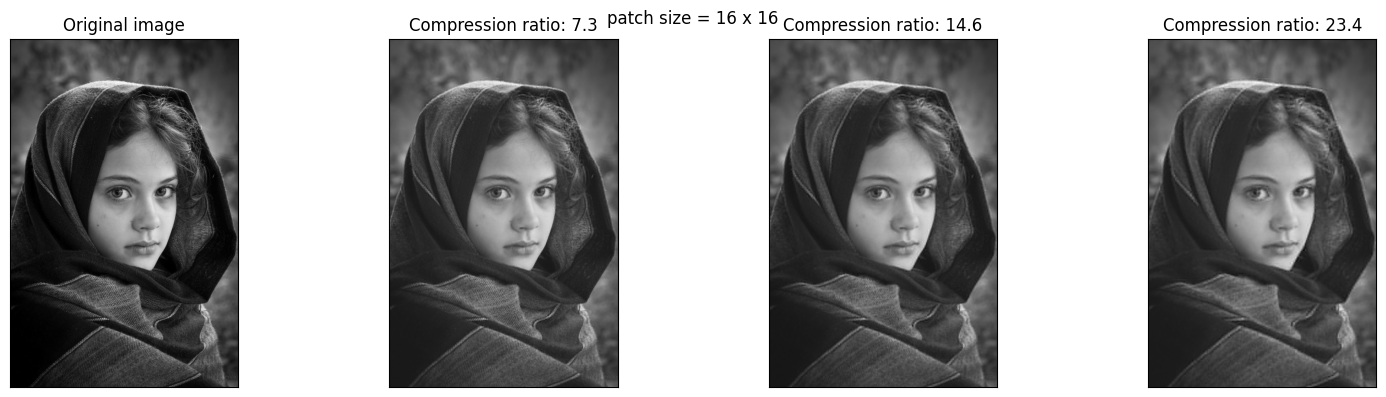

In [11]:
from skimage.util import view_as_windows

imgfile = "pictures/afghan_girl_3.jpg" # 683x1024x3
X = io.imread(imgfile, as_gray = True)

# 將圖像切割小區域
N, p = X.shape # 
patch_sz = 16
patches = view_as_windows(X, (patch_sz, patch_sz), \
                                 step=patch_sz)
M = patches.reshape(-1, patch_sz * patch_sz) # flatten the patches
U, E, VT = svd(M, full_matrices = False)
q = (min(M.shape[0], M.shape[1]) / np.array([1, 8, 16, 24])).astype('int') # how many components (dimensions) to keep

fig, ax = plt.subplots(1, len(q), figsize=(16, 4))
for i, r in enumerate(q):
    Mq = U[:, :r] @ np.diag(E[:r]) @ VT[:r, :] 
    ax[i].imshow(montage(Mq, int(N/patch_sz), int(p/patch_sz)), cmap = 'gray')
    ratio = M.shape[1] * M.shape[0] / (U.shape[0] + VT.shape[1] + 1) / r
    if i >= 1:
        ax[i].set_title('Compression ratio: {:.1f}'.format(ratio))
    else:
        ax[i].set_title('Original image') 
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.suptitle("patch size = {} x {}".format(patch_sz, patch_sz))
plt.show()

FFT compression

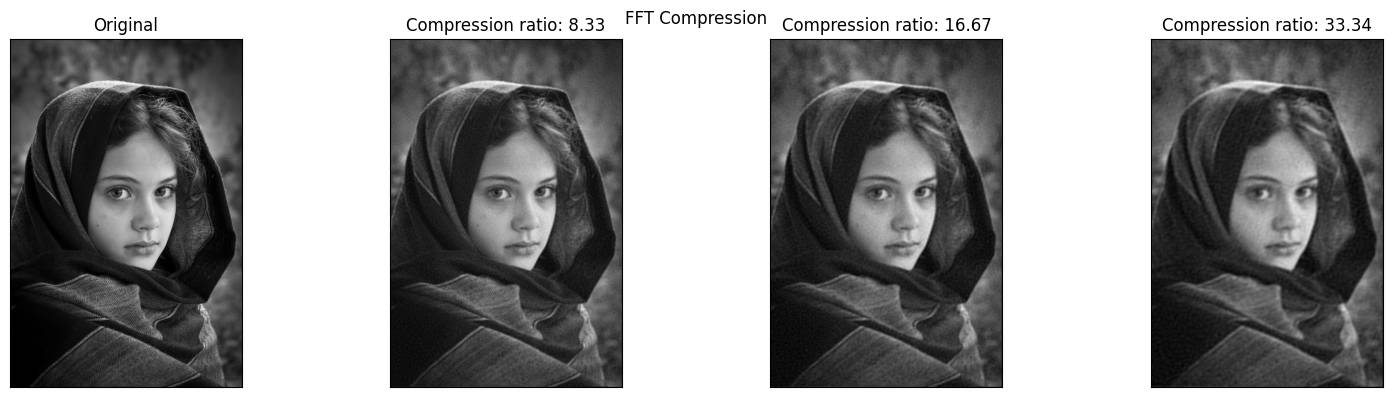

In [12]:
# from scipy.fftpack import fft2, ifft2
from numpy.fft import fft2, ifft2, fftshift

# Load an image as a numpy array
imgfile = "pictures/afghan_girl_3.jpg" # 683x1024x3
X = io.imread(imgfile, as_gray = True)

# Compute the 2D FFT of the image
fft_img = fft2(X)

# Keep only q% of the coefficients by setting the rest to zero
q = np.array([100, 4, 2, 1]) / 100 # how many coefficients to keep
fig, ax = plt.subplots(1, 4, figsize=(16, 4))
for i, r in enumerate(q):
    n = int(r * fft_img.size)
    tmp = fft_img.ravel()
    tmp[np.argsort(abs(tmp))[:-n]] = 0 # keep the n largest coefficients, set the rest to zero
    compressed_img = ifft2(tmp.reshape(fft_img.shape)).real
    # Compute the compression ratio as the ratio of original size to compressed size
    compression_ratio = X.size / (3 * n) # 3n = n + 2n (the position (i,j) of non-zeros)
    ax[i].imshow(compressed_img, cmap = 'gray')
    if i == 0:
        ax[i].set_title('Original')
    else:
        ax[i].set_title('Compression ratio: {:.2f}'.format(compression_ratio))
    ax[i].set_xticks([])
    ax[i].set_yticks([])

plt.tight_layout()
plt.suptitle("FFT Compression")
plt.show()

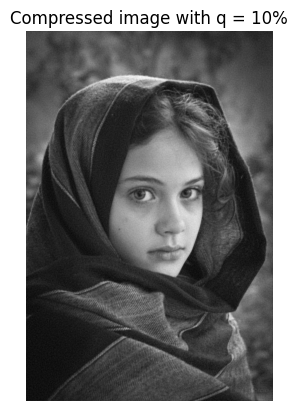

In [13]:
fft_img = fft2(X)
# Keep only q% of the coefficients by setting the rest to zero
q = 10
n = int(q / 100 * fft_img.size)
tmp = fft_img.ravel()
tmp[np.argsort(abs(tmp))[:-n]] = 0
compressed_img = ifft2(tmp.reshape(fft_img.shape)).real
plt.imshow(compressed_img, cmap='gray')
plt.title('Compressed image with q = {}%'.format(q))
plt.axis('off')
plt.show()